## Sympy assignment

Exercise 1: Duffing Oscillator

Scenario: You are studying the potential energy of a "Duffing Oscillator" (a mass on a spring that gets stiffer as it stretches).
The potential is given by: $V(x) = \frac{1}{2}\alpha x^2 + \frac{1}{4}\beta x^4$.


Symbolic: Use SymPy to find the expression for the Force ($F = -dV/dx$).

The Bridge: Use sp.lambdify to turn your symbolic Force expression into a NumPy-ready function.

Numerical: Assuming $\alpha = 1$ and $\beta = 0.5$, plot the Force vs. Position from $x = -2$ to $x = 2$.

Derivative:


1.0*alpha*x + 1.0*beta*x**3

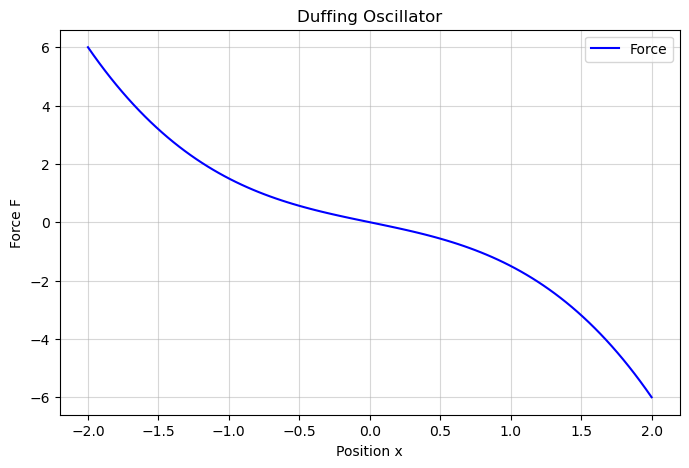

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
                                    #symbolsss
x, V = sp.symbols(' x V')
omega, kappa = sp.symbols('omega kappa', real=True, positive=True)

alpha, beta = sp.symbols('alpha beta')
expr = 0.5 * alpha * x**2 + 0.25 * beta * x**4
                                #derviative 
#f = -dV / dx
dVdx = sp.diff(expr, x)

alpha_val = 1
beta_val = 0.5
V.subs({alpha: alpha_val, beta : beta_val})

print("Derivative:")
display(dVdx) 
                                    #plotting 

fast_force = sp.lambdify(x, -dVdx.subs({alpha: alpha_val, beta: beta_val}), 'numpy')

x_vals = np.linspace(-2, 2, 100)
y_vals = fast_force(x_vals)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, 'b-', label="Force")
plt.title("Duffing Oscillator")
plt.xlabel("Position x")
plt.ylabel("Force F")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()


### Exercise 2: Solving the Damped Oscillator (ODEs)

You are studying a damped spring: $\ddot{x} + \gamma \dot{x} + \omega_0^2 x = 0$.

Your Tasks:

Define $x$ as a sp.Function and $t, \gamma, \omega_0$ as symbols.

Build the ODE: Use sp.Eq and .diff(t).

Solve for General Solution: Use sp.dsolve.

The Overdamped Case: Use .subs() to replace $\gamma$ with $5$ and $\omega_0$ with $2$. Look at the result—does it contain sines/cosines or exponentials?

In [2]:
import sympy as sp

# Define symbols and function
t = sp.symbols('t')
gamma, omega_0 = sp.symbols('gamma omega_0')
x = sp.Function('x')

# Build the ODE
ode = sp.Eq(x(t).diff(t, 2) + gamma * x(t).diff(t) + omega_0**2 * x(t), 0)

# Solve general solution
sol = sp.dsolve(ode)

# Overdamped case: substitute gamma=5, omega_0=2
over = sol.subs({gamma: 5, omega_0: 2})

print("General solution of the damped harmonic oscillator:")
print(sol)
print("\nOverdamped case (gamma=5, omega_0=2):")
print(over)


General solution of the damped harmonic oscillator:
Eq(x(t), C1*exp(t*(-gamma + sqrt(gamma**2 - 4*omega_0**2))/2) + C2*exp(-t*(gamma + sqrt(gamma**2 - 4*omega_0**2))/2))

Overdamped case (gamma=5, omega_0=2):
Eq(x(t), C1*exp(-t) + C2*exp(-4*t))
